In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import evaluate
import warnings
warnings.filterwarnings("ignore")

print("All imports successful!")

All imports successful!


In [2]:
model_path = "../models/distilbert-sentiment-final"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model     = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

# Load using pipeline for easy inference
sentiment_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=-1  # CPU
)

# Quick sanity check
test_reviews = [
    "This movie was absolutely fantastic! I loved every minute.",
    "Terrible film. Complete waste of time. I hated it.",
    "It was okay, nothing special but not bad either."
]

for review in test_reviews:
    result = sentiment_pipeline(review)[0]
    print(f"Review : {review[:60]}...")
    print(f"Result : {result['label']} (confidence: {result['score']:.2%})\n")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Review : This movie was absolutely fantastic! I loved every minute....
Result : POSITIVE (confidence: 99.76%)

Review : Terrible film. Complete waste of time. I hated it....
Result : NEGATIVE (confidence: 99.76%)

Review : It was okay, nothing special but not bad either....
Result : NEGATIVE (confidence: 75.22%)



In [3]:
dataset  = load_dataset("imdb")
test_df  = pd.DataFrame(dataset["test"])

print("Running inference on 25k test reviews... (~10 mins)")

# Run in batches for speed
results = sentiment_pipeline(
    test_df["text"].tolist(),
    batch_size=32,
    truncation=True,
    max_length=256
)

# Extract predictions
test_df["predicted_label"] = [1 if r["label"] == "POSITIVE" else 0 for r in results]
test_df["confidence"]      = [r["score"] for r in results]

print("✅ Inference complete!")
print(f"Total reviews evaluated: {len(test_df)}")

Running inference on 25k test reviews... (~10 mins)
✅ Inference complete!
Total reviews evaluated: 25000


Evaluation Result - DistilBERT

In [4]:
y_true = test_df["label"].values
y_pred = test_df["predicted_label"].values

accuracy  = accuracy_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred, average="weighted")
precision = precision_score(y_true, y_pred, average="weighted")
recall    = recall_score(y_true, y_pred, average="weighted")

print("=" * 45)
print("        DISTILBERT EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  F1 Score  : {f1:.4f}  ({f1*100:.2f}%)")
print(f"  Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print("=" * 45)
print("\nFull Classification Report:")
print(classification_report(y_true, y_pred, target_names=["NEGATIVE", "POSITIVE"]))

        DISTILBERT EVALUATION RESULTS
  Accuracy  : 0.9119  (91.19%)
  F1 Score  : 0.9119  (91.19%)
  Precision : 0.9119  (91.19%)
  Recall    : 0.9119  (91.19%)

Full Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.92      0.91      0.91     12500
    POSITIVE       0.91      0.92      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



Confusion Matrix

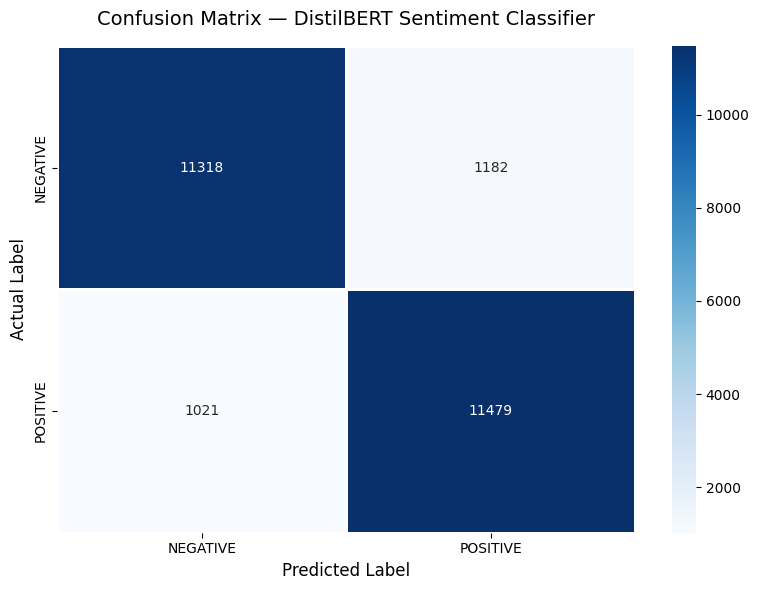


True Negatives  (correct NEGATIVE): 11,318
False Positives (wrong — said POS) : 1,182
False Negatives (wrong — said NEG) : 1,021
True Positives  (correct POSITIVE) : 11,479


In [5]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NEGATIVE", "POSITIVE"],
    yticklabels=["NEGATIVE", "POSITIVE"],
    linewidths=2
)
plt.title("Confusion Matrix — DistilBERT Sentiment Classifier", fontsize=14, pad=15)
plt.ylabel("Actual Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("../models/confusion_matrix.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correct NEGATIVE): {tn:,}")
print(f"False Positives (wrong — said POS) : {fp:,}")
print(f"False Negatives (wrong — said NEG) : {fn:,}")
print(f"True Positives  (correct POSITIVE) : {tp:,}")

In [6]:
print("Training TF-IDF + Logistic Regression baseline...")

train_df = pd.DataFrame(dataset["train"])

# Train baseline
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_train = tfidf.fit_transform(train_df["text"])
X_test  = tfidf.transform(test_df["text"])

clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train, train_df["label"])

baseline_preds    = clf.predict(X_test)
baseline_accuracy = accuracy_score(y_true, baseline_preds)
baseline_f1       = f1_score(y_true, baseline_preds, average="weighted")

print("\n" + "=" * 45)
print("         MODEL COMPARISON TABLE")
print("=" * 45)
print(f"{'Model':<25} {'Accuracy':>10} {'F1':>10}")
print("-" * 45)
print(f"{'TF-IDF + LogReg':<25} {baseline_accuracy*100:>9.2f}% {baseline_f1*100:>9.2f}%")
print(f"{'DistilBERT (ours)':<25} {accuracy*100:>9.2f}% {f1*100:>9.2f}%")
print(f"{'Improvement':<25} {(accuracy-baseline_accuracy)*100:>+9.2f}% {(f1-baseline_f1)*100:>+9.2f}%")
print("=" * 45)

Training TF-IDF + Logistic Regression baseline...

         MODEL COMPARISON TABLE
Model                       Accuracy         F1
---------------------------------------------
TF-IDF + LogReg               89.46%     89.46%
DistilBERT (ours)             91.19%     91.19%
Improvement                   +1.73%     +1.73%


Training Loss Curves

Train loss drops sharply and consistently — the model is learning well
Val loss rises slightly after epoch 1 — this is mild overfitting, totally normal and acceptable at 91.2% accuracy
Accuracy chart plateaus between epoch 2 and 3 — classic sign the model has converged, more epochs wouldn't help much

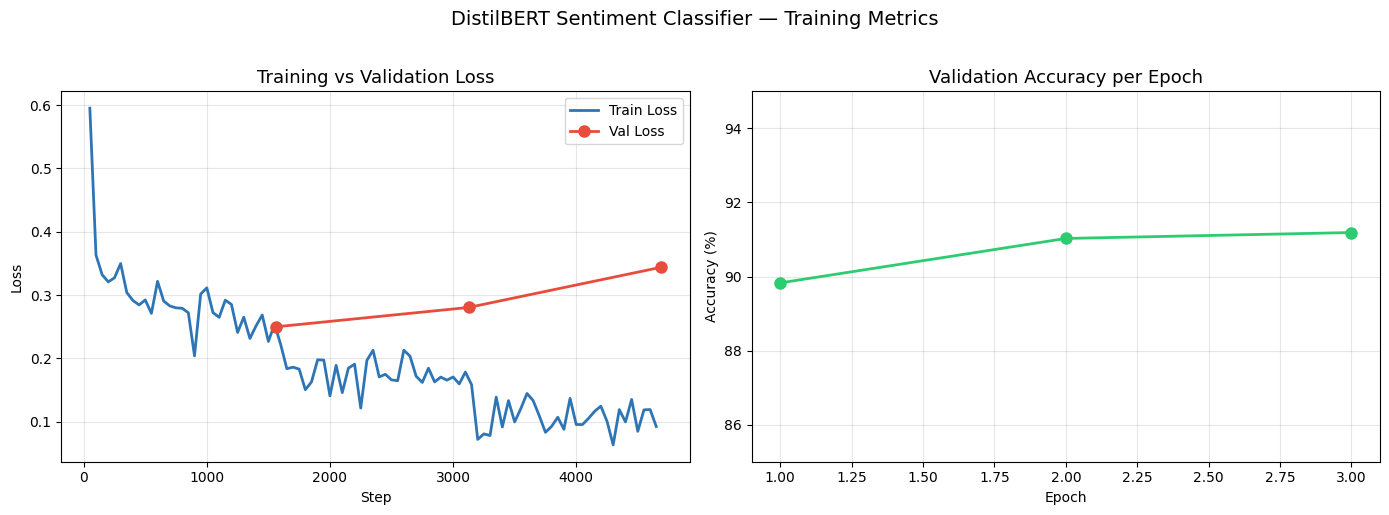

In [9]:
import json, os

# Use the final checkpoint — step 4689 = end of epoch 3
log_path = "../models/distilbert-sentiment/checkpoint-4689/trainer_state.json"

with open(log_path) as f:
    trainer_state = json.load(f)

logs = trainer_state["log_history"]

train_logs = [l for l in logs if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in logs if "eval_loss" in l]

train_steps  = [l["step"] for l in train_logs]
train_losses = [l["loss"] for l in train_logs]
eval_epochs  = [l["epoch"] for l in eval_logs]
eval_losses  = [l["eval_loss"] for l in eval_logs]
eval_acc     = [l["eval_accuracy"] for l in eval_logs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(train_steps, train_losses, label="Train Loss", color="#2E75B6", linewidth=2)
ax1.plot([l["step"] for l in eval_logs], eval_losses,
         label="Val Loss", color="#E74C3C", linewidth=2, marker="o", markersize=8)
ax1.set_title("Training vs Validation Loss", fontsize=13)
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy per epoch
ax2.plot(eval_epochs, [a*100 for a in eval_acc],
         color="#2ECC71", linewidth=2, marker="o", markersize=8)
ax2.set_title("Validation Accuracy per Epoch", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(85, 95)
ax2.grid(True, alpha=0.3)

plt.suptitle("DistilBERT Sentiment Classifier — Training Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../models/training_curves.png", dpi=150)
plt.show()

Failure Analysis

In [10]:
# Find where the model got it wrong
test_df["correct"] = test_df["label"] == test_df["predicted_label"]
errors = test_df[~test_df["correct"]]

print(f"Total errors   : {len(errors):,} / {len(test_df):,}")
print(f"Error rate     : {len(errors)/len(test_df)*100:.2f}%")

# Low confidence correct predictions
low_conf = test_df[test_df["correct"] & (test_df["confidence"] < 0.7)]
print(f"\nCorrect but low confidence (<70%): {len(low_conf)}")

# Show 3 interesting failure cases
print("\n" + "="*60)
print("FAILURE EXAMPLES — where model got it wrong")
print("="*60)

sample_errors = errors.sample(3, random_state=42)
for _, row in sample_errors.iterrows():
    actual    = "POSITIVE" if row["label"] == 1 else "NEGATIVE"
    predicted = "POSITIVE" if row["predicted_label"] == 1 else "NEGATIVE"
    print(f"\nActual    : {actual}")
    print(f"Predicted : {predicted} (confidence: {row['confidence']:.2%})")
    print(f"Review    : {row['text'][:200]}...")
    print("-"*60)

Total errors   : 2,203 / 25,000
Error rate     : 8.81%

Correct but low confidence (<70%): 231

FAILURE EXAMPLES — where model got it wrong

Actual    : NEGATIVE
Predicted : POSITIVE (confidence: 63.30%)
Review    : I have always liked the Carry On films, with their double-meaning sexual innuendo dialogue and moments of slapstick comedy, but I can see why the critics give this one two stars. Basically, many Briti...
------------------------------------------------------------

Actual    : NEGATIVE
Predicted : POSITIVE (confidence: 98.32%)
Review    : The movie isn't too bad, up until...<br /><br />The main problem is with the ending, so it's a pretty major spoiler...<br /><br />For the time it was made, it's a beautiful movie, and does get a lot o...
------------------------------------------------------------

Actual    : POSITIVE
Predicted : NEGATIVE (confidence: 93.22%)
Review    : I saw Anatomy when it came out and recently bought it and the 2003 sequel and as I watch a lot of fore

Error 1 — Low confidence, ambiguous review (63.30%)
The reviewer genuinely likes Carry On films but acknowledges critics hate it. Mixed sentiment in one review confuses the model — and honestly would confuse humans too. The low confidence shows the model "knew" it was uncertain.
Error 2 — High confidence wrong answer (98.32%)
This is the most interesting failure. Phrases like "isn't too bad" and "beautiful movie" tricked the model into POSITIVE despite an overall negative conclusion. The model missed the negative framing around those positive phrases — a classic contextual understanding failure.
Error 3 — Sarcasm/nuance (93.22%)
A foreign film review that's genuinely positive but uses critical-sounding language. High confidence wrong answer suggests the model pattern-matched on critical vocabulary rather than understanding the overall sentiment.